In [386]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Generation of Convex Polygon

In [387]:
def generate_convex_polygon(n=8):
    angles = np.sort(np.random.rand(n) * 2 * np.pi)
    points = np.array([[np.cos(angle), np.sin(angle)] for angle in angles])
    points *= np.random.uniform(1, 5)

    shift_x, shift_y = np.random.uniform(-5, 5, size=2)
    points[:, 0] += shift_x
    points[:, 1] += shift_y

    return points

In [388]:
def plot_with_line(plot_func):
    def wrapper(polygon, polygon_changed=None, line_points=None):
        plot_func(polygon, polygon_changed)

        if line_points is not None:
            p1, p2 = line_points
            k = (p2[1] - p1[1]) / (p2[0] - p1[0]) if p2[0] != p1[0] else None

            if k is not None:
                x_vals = np.array([-10, 10])
                y_vals = k * (x_vals - p1[0]) + p1[1]
            else:
                x_vals = np.full(2, p1[0])
                y_vals = np.array([-10, 10])

            plt.plot(x_vals, y_vals, 'r-', linewidth=2)

            plt.scatter(*p1, color='yellow', s=100, marker='o')
            plt.scatter(*p2, color='yellow', s=100, marker='o')
        plt.show()

    return wrapper

@plot_with_line
def plot_polygon(polygon, polygon_changed=None):
    plt.figure(figsize=(8, 8))
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.xticks(np.arange(-10, 11, 1))
    plt.yticks(np.arange(-10, 11, 1))
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.plot(np.append(polygon[:, 0], polygon[0, 0]),
         np.append(polygon[:, 1], polygon[0, 1]), 'bo-', markersize=8)
    plt.fill(polygon[:, 0], polygon[:, 1], "purple", alpha=0.3)

    if polygon_changed is not None:
        plt.plot(np.append(polygon_changed[:, 0], polygon_changed[0, 0]),
             np.append(polygon_changed[:, 1], polygon_changed[0, 1]), 'go-', markersize=8)
        plt.fill(polygon_changed[:, 0], polygon_changed[:, 1], 'lightgreen', alpha=0.3)

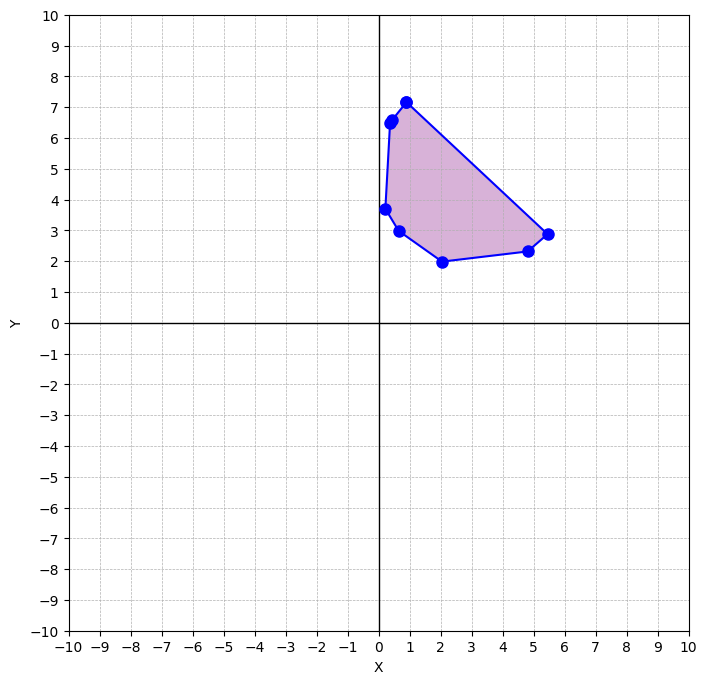

In [389]:
polygon = generate_convex_polygon()

plot_polygon(polygon)

### Scaling Polygon

In [390]:
def scaling_polygon(points, scale_factor=1.5):
    center_mass = points.mean(axis=0)

    points_homogeneous = np.column_stack((points, np.ones(points.shape[0])))

    T_to_origin = np.array([[1, 0, -center_mass[0]],
                            [0, 1, -center_mass[1]],
                            [0, 0, 1]])

    S = np.array([[1/scale_factor, 0, 0],
                  [0, 1/scale_factor, 0],
                  [0, 0, 1]])

    T_back = np.array([[1, 0, center_mass[0]],
                       [0, 1, center_mass[1]],
                       [0, 0, 1]])

    transformation_matrix = T_back @ S @ T_to_origin
    transformed_points_homogeneous = points_homogeneous @ transformation_matrix.T

    return transformed_points_homogeneous[:, :2]

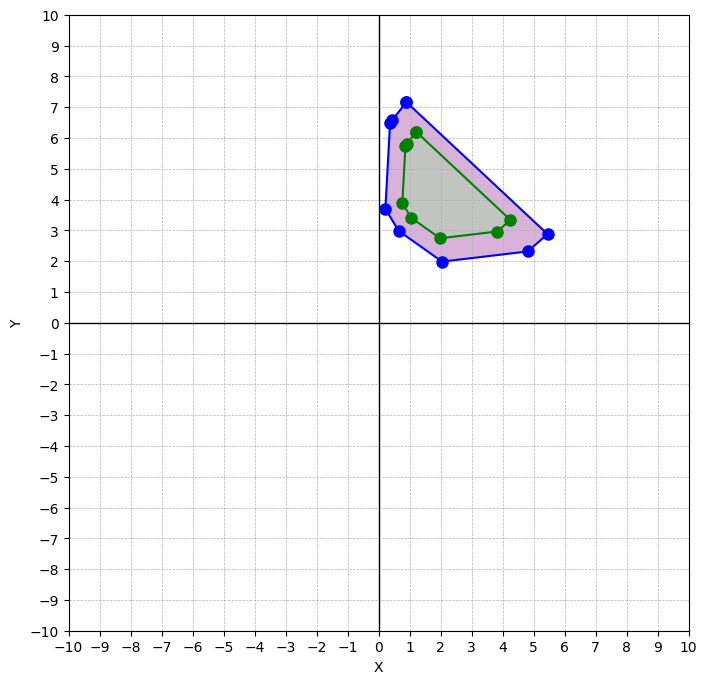

In [391]:
polygon_scaled = scaling_polygon(polygon, scale_factor=1.5)

plot_polygon(polygon, polygon_scaled)

### Reflecting Polygon

In [392]:
def reflect_polygon(points):
    points_homogeneous = np.column_stack((points, np.ones(points.shape[0])))

    R = np.array([[-1, 0, 0],
                  [0, -1, 0],
                  [0, 0, 1]])

    reflected_points_homogeneous = points_homogeneous @ R.T
    return reflected_points_homogeneous[:, :2]

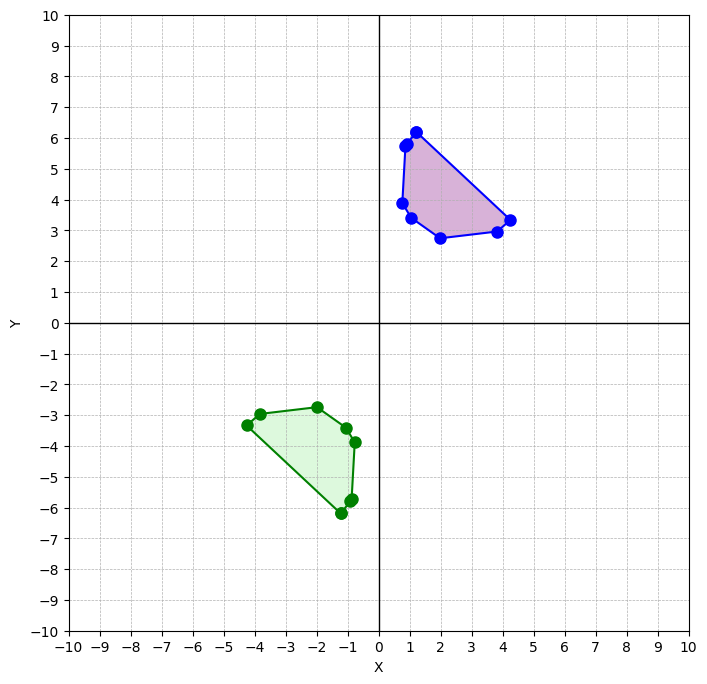

In [393]:
polygon_reflected = reflect_polygon(polygon_scaled)
plot_polygon(polygon_scaled, polygon_reflected)

### Reflaction relative to a straight line

In [394]:
def reflect_line_polygon(polygon, p1, p2):
    theta = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    T = np.array([[1, 0, -p1[0]],
                  [0, 1, -p1[1]],
                  [0, 0, 1]])

    R = np.array([[np.cos(theta), np.sin(theta), 0],
                  [-np.sin(theta), np.cos(theta), 0],
                  [0, 0, 1]])

    M = np.array([[1, 0, 0],
                  [0, -1, 0],
                  [0, 0, 1]])

    R_inv = np.linalg.inv(R)

    T_inv = np.linalg.inv(T)

    polygon_homogeneous = np.hstack((polygon, np.ones((polygon.shape[0], 1))))

    reflected_polygon = T_inv @ R_inv @ M @ R @ T @ polygon_homogeneous.T
    reflected_polygon = reflected_polygon.T[:, :2]

    return reflected_polygon

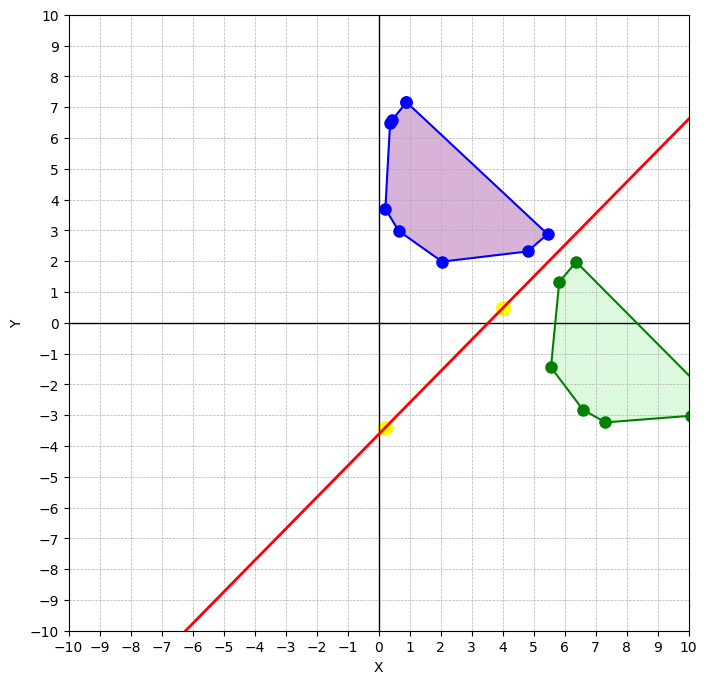

In [395]:
p1 = np.random.rand(2) * 10 - 5
p2 = np.random.rand(2) * 10 - 5
reflected_polygon = reflect_line_polygon(polygon, p1, p2)

plot_polygon(polygon, reflected_polygon, line_points=(p1, p2))

### Dealing with a Figure

In [396]:
def plot_figure_with_line(plot_func):
    def wrapper(polygon, polygon_changed=None, line_points=None):
        plot_func(polygon, polygon_changed)

        if line_points is not None:
            p1, p2 = line_points
            k = (p2[1] - p1[1]) / (p2[0] - p1[0]) if p2[0] != p1[0] else None

            x_min, x_max = plt.xlim()
            y_min, y_max = plt.ylim()

            if k is not None:
                x_vals = np.array([x_min, x_max])
                y_vals = k * (x_vals - p1[0]) + p1[1]

                y_vals = np.clip(y_vals, y_min, y_max)
            else:
                x_vals = np.full(2, p1[0])
                y_vals = np.array([y_min, y_max])

            plt.plot(x_vals, y_vals, 'r-', linewidth=2)

            plt.scatter(*p1, color='yellow', s=100, marker='o')
            plt.scatter(*p2, color='yellow', s=100, marker='o')

        plt.show()

    return wrapper

@plot_figure_with_line
def plot_figure(polygon, polygon_changed=None):
    plt.figure(figsize=(15, 15))
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.xlim(-150, 150)
    plt.ylim(-150, 150)
    plt.xticks(np.arange(-150, 151, 10))
    plt.yticks(np.arange(-150, 151, 10))
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.plot(np.append(polygon[:, 0], polygon[0, 0]),
         np.append(polygon[:, 1], polygon[0, 1]), 'bo-', markersize=8)

    if polygon_changed is not None:
        plt.plot(np.append(polygon_changed[:, 0], polygon_changed[0, 0]),
             np.append(polygon_changed[:, 1], polygon_changed[0, 1]), 'go-', markersize=8)


In [397]:
file_path = 'Варіанти.xlsx'

excel_file = pd.ExcelFile(file_path)
sheet = excel_file.parse(excel_file.sheet_names[0])

x_coordinates = sheet.iloc[:, 0].to_numpy()
y_coordinates = sheet.iloc[:, 1].to_numpy()

figure = np.column_stack((x_coordinates, y_coordinates))

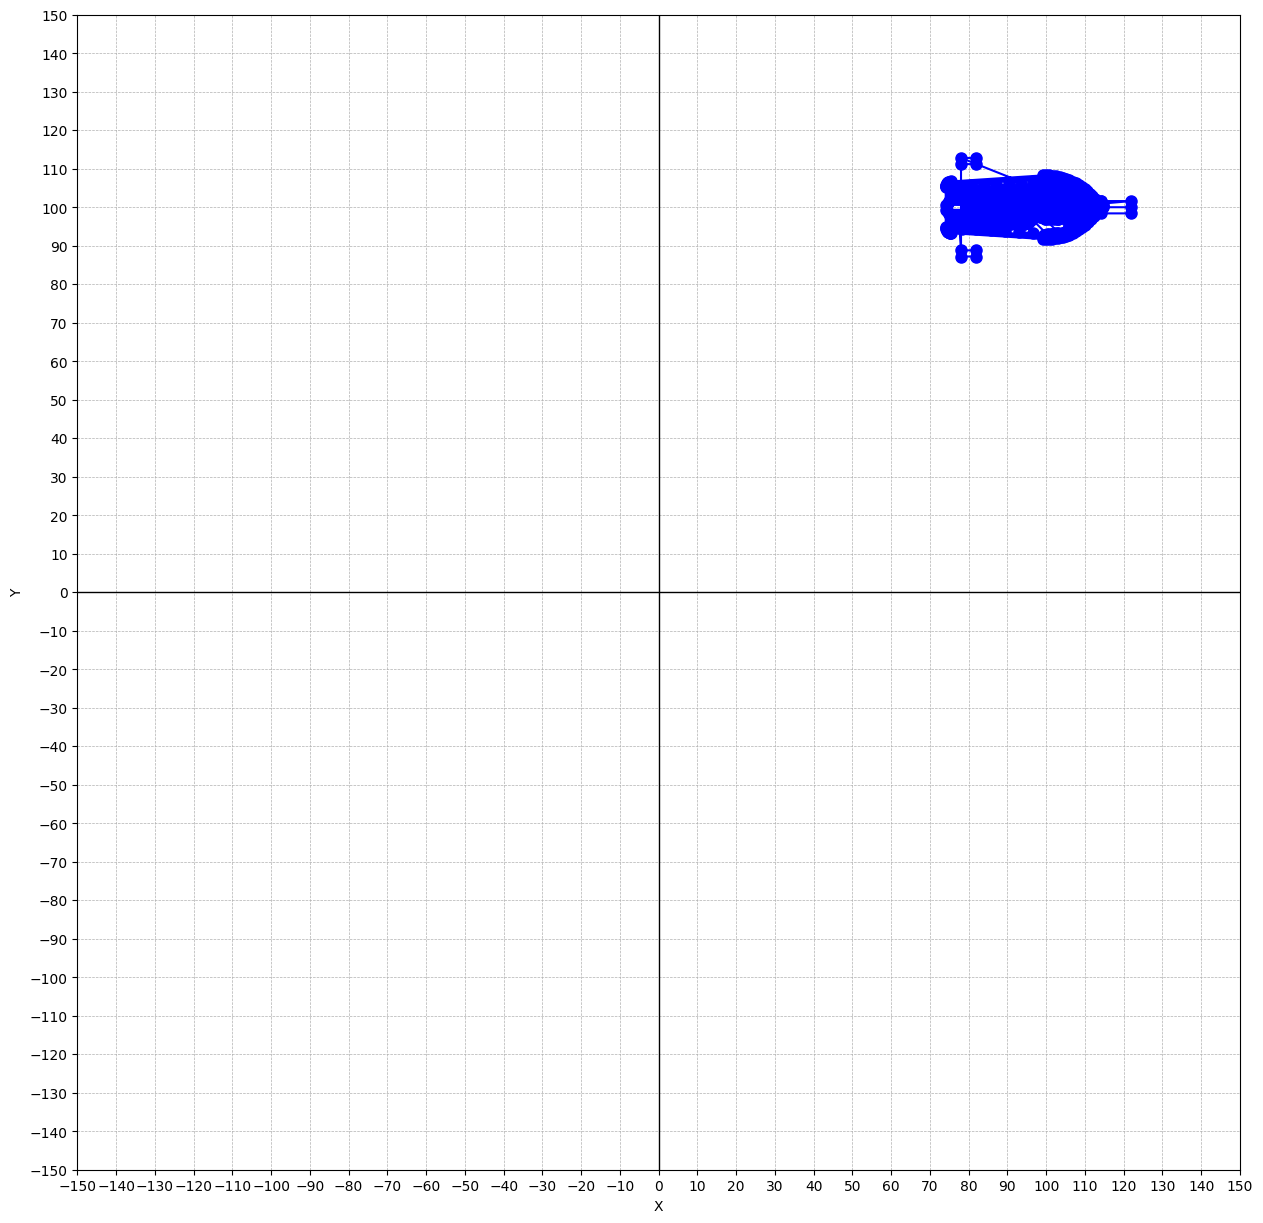

In [398]:
plot_figure(figure)

### Scaling

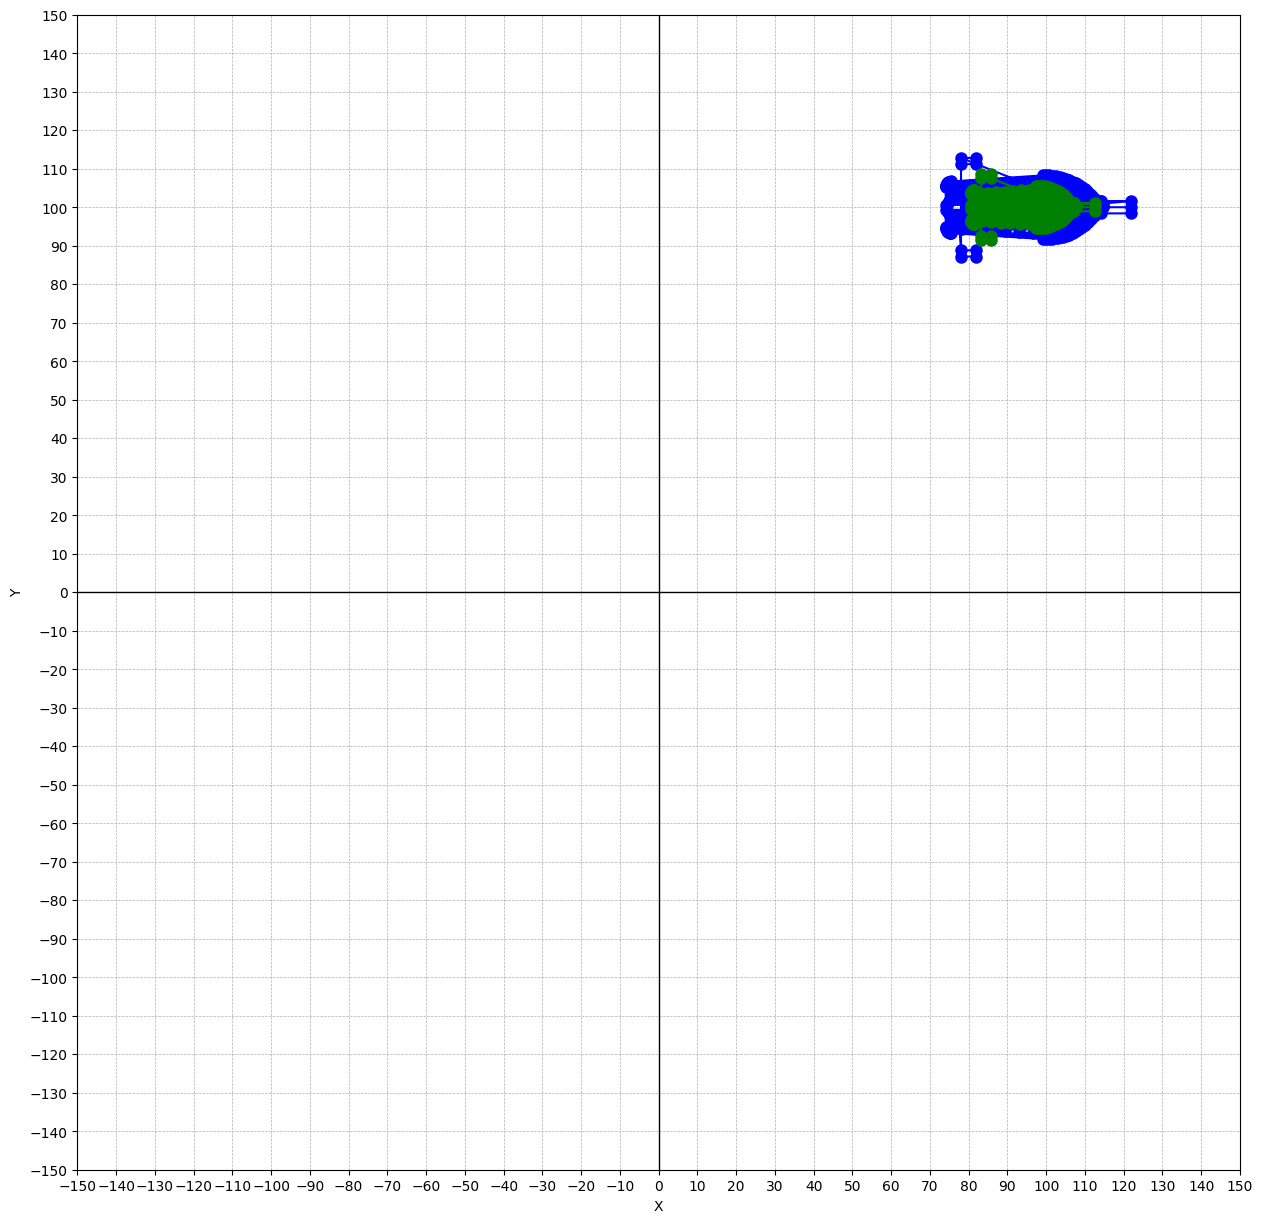

In [399]:
scaled_figure = scaling_polygon(figure)

plot_figure(figure, scaled_figure)

### Reflecting

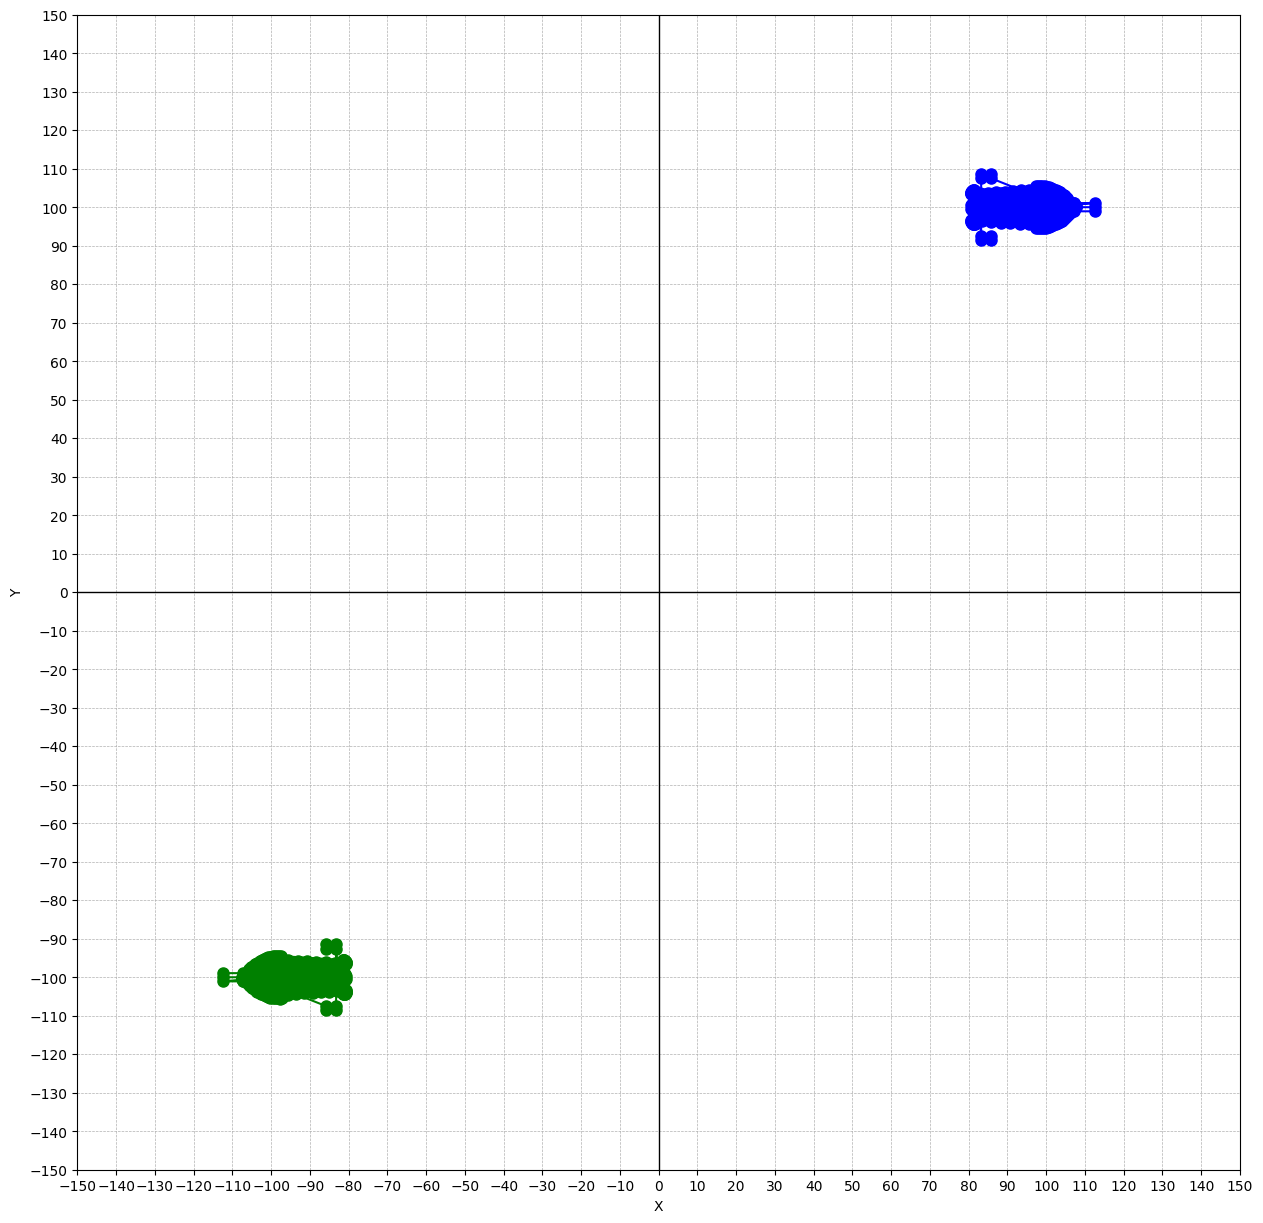

In [400]:
reflected_figure = reflect_polygon(scaled_figure)

plot_figure(scaled_figure, reflected_figure)

### Reflaction relative to a straight line

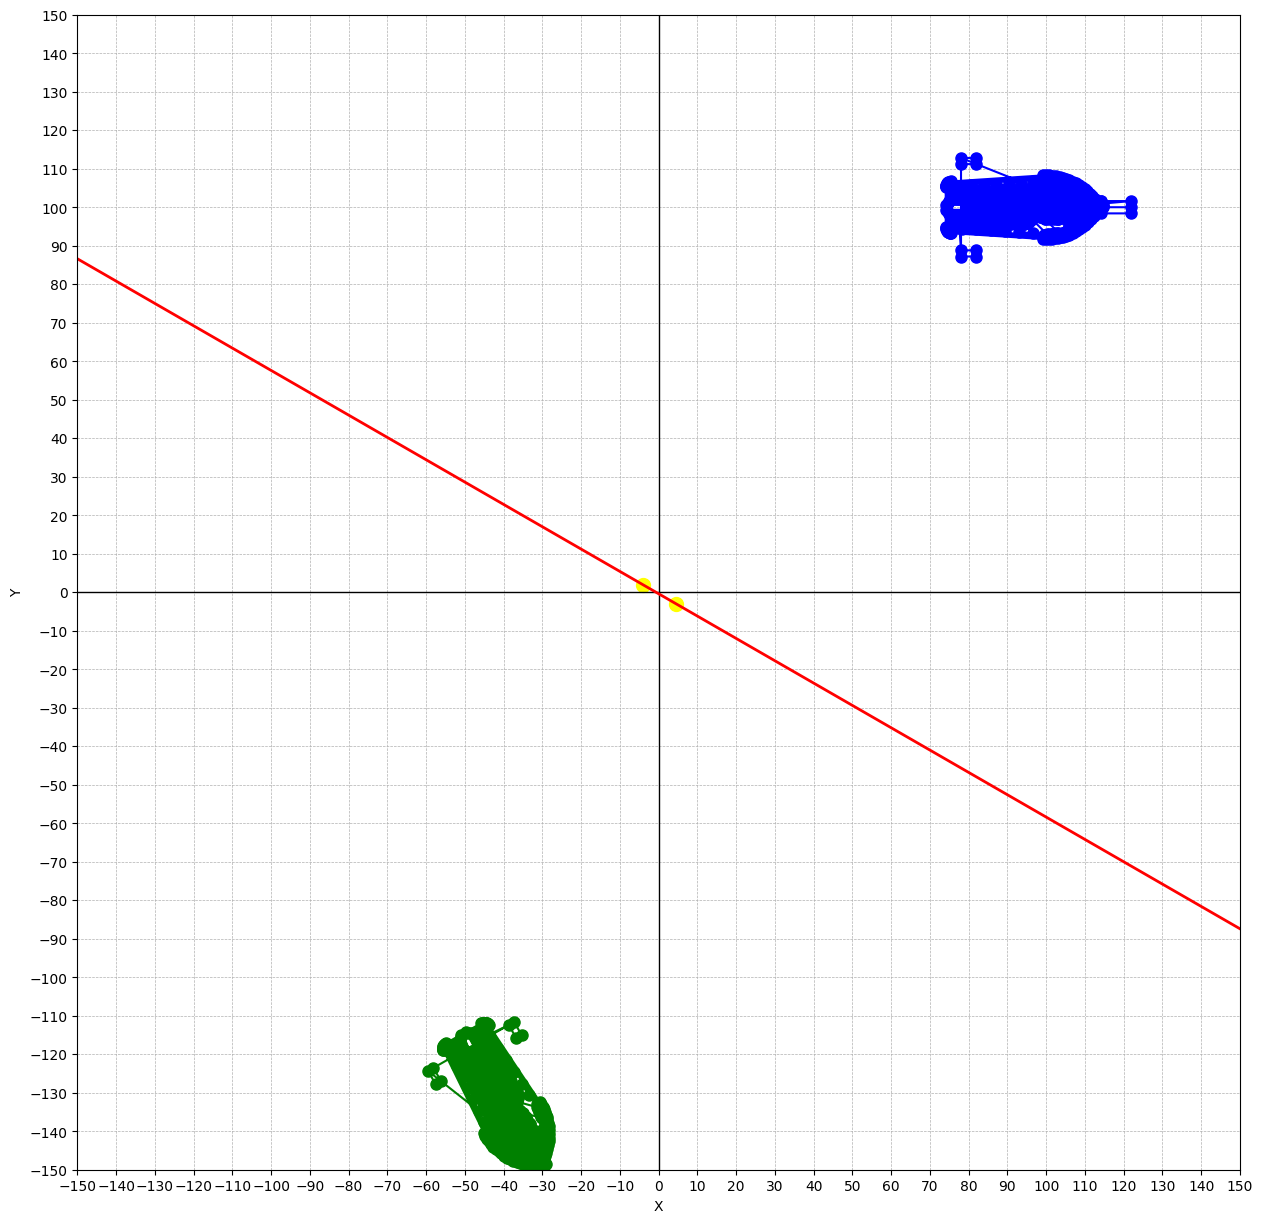

In [401]:
p1 = np.random.rand(2) * 10 - 5
p2 = np.random.rand(2) * 10 - 5
figure_reflected = reflect_line_polygon(figure, p1, p2)

plot_figure(figure, figure_reflected, line_points=(p1, p2))